In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from pathlib import Path
import numpy as np

base_path = Path("ETAPA 4 - CLUSTERING/outputs")

files = {
    "armenia": base_path / "armenia_clusters_final_extra.csv",
    "cali": base_path / "cali_clusters_final_extra.csv",
    "pereira": base_path / "pereira_clusters_final_extra.csv",
}

for city, path_file in files.items():
    # Leer archivo final
    df = pd.read_csv(path_file, low_memory=False)

    # Asegurar tipos
    df["COD_DANE_ANM"] = df["COD_DANE_ANM"].astype(str)

    # Si no existe estrato_promedio pero sí VA1_ESTRATO, lo crea
    if "estrato_promedio" not in df.columns and "VA1_ESTRATO" in df.columns:
        df["VA1_ESTRATO"] = pd.to_numeric(df["VA1_ESTRATO"], errors="coerce")
        df.loc[~df["VA1_ESTRATO"].between(1, 6), "VA1_ESTRATO"] = np.nan
        df["estrato_promedio"] = df["VA1_ESTRATO"]

    # Crear grupo de estrato si no existe
    if "estrato_grupo_mza" not in df.columns and "estrato_promedio" in df.columns:
        def clasificar_estrato(x):
            if pd.isna(x):
                return np.nan
            elif x <= 2:
                return "Bajo"
            elif x <= 4:
                return "Medio"
            else:
                return "Alto"

        df["estrato_grupo_mza"] = df["estrato_promedio"].apply(clasificar_estrato)

    # Convertir WKT a geometría
    df["geometry"] = df["GEOM_WKT"].apply(wkt.loads)

    # Crear GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    # Dejar solo columnas útiles para QGIS
    cols_keep = [
        "COD_DANE_ANM",
        "estrato_promedio",
        "estrato_grupo_mza",
        "geometry"
    ]
    cols_keep = [c for c in cols_keep if c in gdf.columns]

    gdf_out = gdf[cols_keep].copy()

    # Guardar GeoJSON
    out_file = base_path / f"estrato_manzanas_{city}.geojson"
    gdf_out.to_file(out_file, driver="GeoJSON")

    print(f"Guardado: {out_file}")

Guardado: ETAPA 4 - CLUSTERING\outputs\estrato_manzanas_armenia.geojson
Guardado: ETAPA 4 - CLUSTERING\outputs\estrato_manzanas_cali.geojson
Guardado: ETAPA 4 - CLUSTERING\outputs\estrato_manzanas_pereira.geojson


In [15]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("ETAPA 4 - CLUSTERING/outputs")

files = {
    "armenia": base_path / "armenia_clusters_final_extra.csv",
    "cali": base_path / "cali_clusters_final_extra.csv",
    "pereira": base_path / "pereira_clusters_final_extra.csv",
}

In [16]:
def cargar_final_extra(path_file):
    df = pd.read_csv(path_file, low_memory=False)
    df["geometry"] = df["GEOM_WKT"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
    return gdf

gdfs = {}

for city, path_file in files.items():
    gdfs[city] = cargar_final_extra(path_file)
    print(city, gdfs[city].shape)

armenia (3190, 41)
cali (13617, 41)
pereira (3988, 41)


In [17]:
for city, gdf in gdfs.items():
    print(f"\n===== {city.upper()} =====")
    print("IND_POBREZA_HAB" in gdf.columns)
    print("estrato_promedio" in gdf.columns)


===== ARMENIA =====
True
True

===== CALI =====
True
True

===== PEREIRA =====
True
True


In [18]:
for city, gdf in gdfs.items():
    df = gdf[["IND_POBREZA_HAB", "estrato_promedio"]].dropna().copy()
    
    corr = df["IND_POBREZA_HAB"].corr(df["estrato_promedio"])
    
    print(f"\n===== CORRELACIÓN: {city.upper()} =====")
    print("Correlación Pearson:", round(corr, 4))


===== CORRELACIÓN: ARMENIA =====
Correlación Pearson: -0.3162

===== CORRELACIÓN: CALI =====
Correlación Pearson: -0.3496

===== CORRELACIÓN: PEREIRA =====
Correlación Pearson: -0.306


In [20]:
for city, gdf in gdfs.items():
    df = gdf[["estrato_promedio", "IND_POBREZA_HAB"]].dropna().copy()
    
    tabla = df.groupby("estrato_promedio")["IND_POBREZA_HAB"].mean().round(3)
    
    print(f"\n===== POBREZA PROMEDIO POR ESTRATO: {city.upper()} =====")
    print(tabla)


===== POBREZA PROMEDIO POR ESTRATO: ARMENIA =====
estrato_promedio
1.000000    0.054
1.004000    0.037
1.005051    0.019
1.006211    0.057
1.006250    0.093
            ...  
5.918605    0.006
5.942029    0.000
5.957746    0.000
5.967213    0.000
6.000000    0.000
Name: IND_POBREZA_HAB, Length: 1817, dtype: float64

===== POBREZA PROMEDIO POR ESTRATO: CALI =====
estrato_promedio
1.000000    0.050
1.003509    0.023
1.003584    0.025
1.003650    0.012
1.003831    0.076
            ...  
5.987179    0.000
5.988679    0.000
5.991071    0.000
5.993197    0.000
6.000000    0.002
Name: IND_POBREZA_HAB, Length: 6388, dtype: float64

===== POBREZA PROMEDIO POR ESTRATO: PEREIRA =====
estrato_promedio
1.000000    0.081
1.006897    0.007
1.009434    0.009
1.010000    0.040
1.010352    0.116
            ...  
5.984000    0.000
5.989011    0.003
5.990291    0.019
5.991632    0.000
6.000000    0.003
Name: IND_POBREZA_HAB, Length: 2123, dtype: float64


<Figure size 700x500 with 0 Axes>

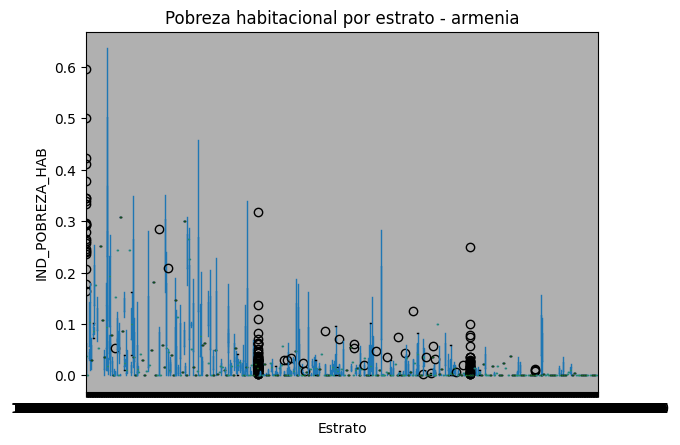

<Figure size 700x500 with 0 Axes>

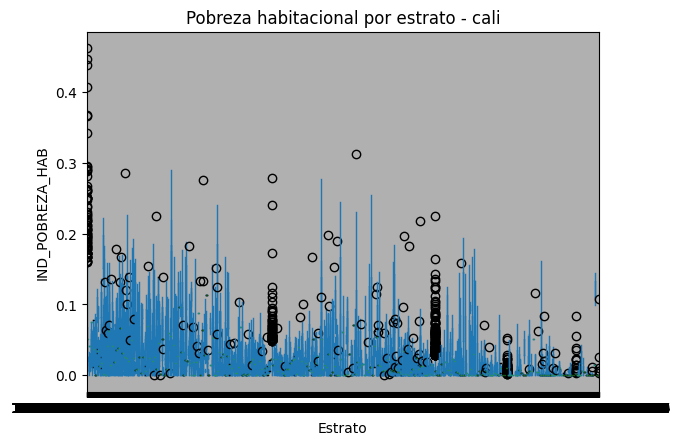

<Figure size 700x500 with 0 Axes>

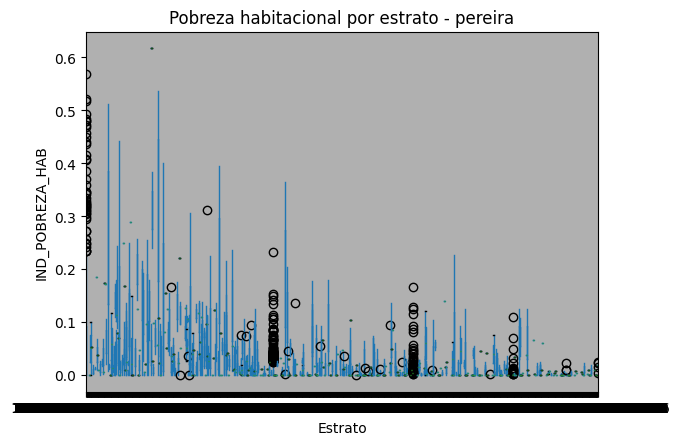

In [10]:
for city, gdf in gdfs.items():
    df = gdf[["estrato_promedio", "IND_POBREZA_HAB"]].dropna().copy()

    plt.figure(figsize=(7,5))
    df.boxplot(column="IND_POBREZA_HAB", by="estrato_promedio")
    plt.title(f"Pobreza habitacional por estrato - {city}")
    plt.suptitle("")
    plt.xlabel("Estrato")
    plt.ylabel("IND_POBREZA_HAB")
    plt.show()

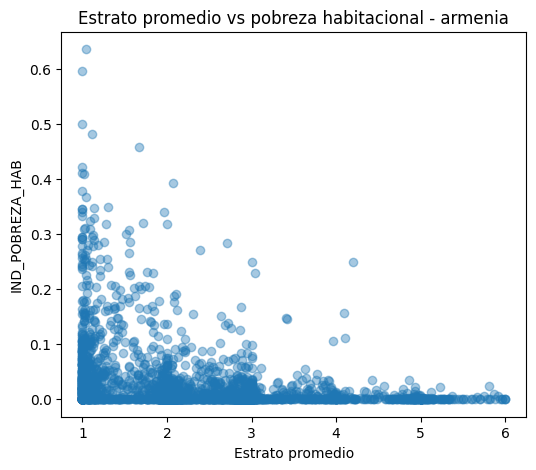

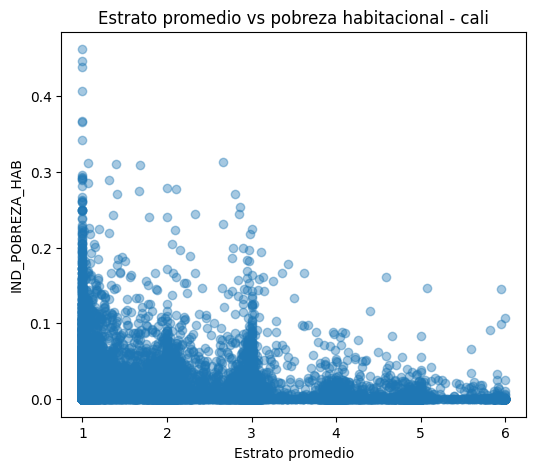

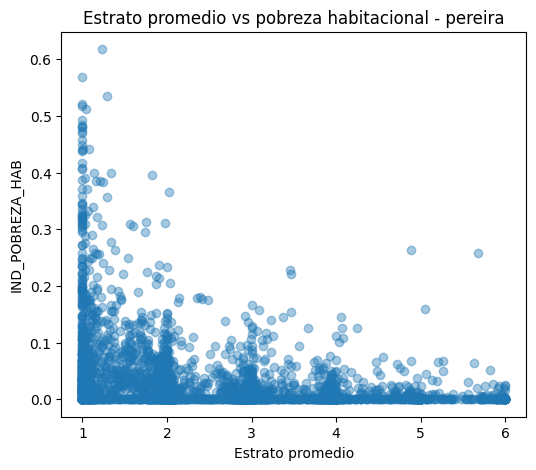

In [11]:
for city, gdf in gdfs.items():
    df = gdf[["estrato_promedio", "IND_POBREZA_HAB"]].dropna().copy()

    plt.figure(figsize=(6,5))
    plt.scatter(df["estrato_promedio"], df["IND_POBREZA_HAB"], alpha=0.4)
    plt.title(f"Estrato promedio vs pobreza habitacional - {city}")
    plt.xlabel("Estrato promedio")
    plt.ylabel("IND_POBREZA_HAB")
    plt.show()

In [21]:
for city, gdf in gdfs.items():

    # -----------------------------
    # NUEVO CRITERIO: CUARTILES
    # -----------------------------
    q1_pob = gdf["IND_POBREZA_HAB"].quantile(0.25)
    q3_pob = gdf["IND_POBREZA_HAB"].quantile(0.75)

    q1_est = gdf["estrato_promedio"].quantile(0.25)
    q3_est = gdf["estrato_promedio"].quantile(0.75)

    # pobreza
    def clas_pobreza(x):
        if pd.isna(x):
            return np.nan
        elif x <= q1_pob:
            return "Baja pobreza"
        elif x >= q3_pob:
            return "Alta pobreza"
        else:
            return "Media"

    # estrato
    def clas_estrato(x):
        if pd.isna(x):
            return np.nan
        elif x <= q1_est:
            return "Estrato bajo"
        elif x >= q3_est:
            return "Estrato alto"
        else:
            return "Estrato medio"

    gdf["pobreza_cat"] = gdf["IND_POBREZA_HAB"].apply(clas_pobreza)
    gdf["estrato_cat"] = gdf["estrato_promedio"].apply(clas_estrato)

    # relación (solo extremos, opcional pero recomendado)
    gdf["relacion_pob_estrato"] = gdf["pobreza_cat"] + " - " + gdf["estrato_cat"]

    gdfs[city] = gdf

In [22]:
for city, gdf in gdfs.items():
    print(f"\n===== RELACIÓN POBREZA-ESTRATO: {city.upper()} =====")
    print(gdf["relacion_pob_estrato"].value_counts())


===== RELACIÓN POBREZA-ESTRATO: ARMENIA =====
relacion_pob_estrato
Baja pobreza - Estrato medio    1008
Baja pobreza - Estrato alto      597
Alta pobreza - Estrato bajo      453
Media - Estrato medio            302
Alta pobreza - Estrato medio     273
Baja pobreza - Estrato bajo      235
Media - Estrato alto             143
Media - Estrato bajo             105
Alta pobreza - Estrato alto       56
Name: count, dtype: int64

===== RELACIÓN POBREZA-ESTRATO: CALI =====
relacion_pob_estrato
Media - Estrato medio           2778
Baja pobreza - Estrato alto     2457
Alta pobreza - Estrato bajo     1818
Media - Estrato alto            1745
Baja pobreza - Estrato medio    1649
Alta pobreza - Estrato medio    1133
Media - Estrato bajo             993
Baja pobreza - Estrato bajo      555
Alta pobreza - Estrato alto      336
Name: count, dtype: int64

===== RELACIÓN POBREZA-ESTRATO: PEREIRA =====
relacion_pob_estrato
Baja pobreza - Estrato medio    1093
Baja pobreza - Estrato alto      587
Media -

In [23]:
for city, gdf in gdfs.items():
    out_file = base_path / f"relacion_pobreza_estrato_quartiles_{city}.geojson"
    
    cols_keep = [
        "COD_DANE_ANM",
        "IND_POBREZA_HAB",
        "estrato_promedio",
        "pobreza_cat",
        "estrato_cat",
        "relacion_pob_estrato",
        "geometry"
    ]
    
    cols_keep = [c for c in cols_keep if c in gdf.columns]
    
    gdf[cols_keep].to_file(out_file, driver="GeoJSON")
    print("Guardado:", out_file)

Guardado: ETAPA 4 - CLUSTERING\outputs\relacion_pobreza_estrato_quartiles_armenia.geojson
Guardado: ETAPA 4 - CLUSTERING\outputs\relacion_pobreza_estrato_quartiles_cali.geojson
Guardado: ETAPA 4 - CLUSTERING\outputs\relacion_pobreza_estrato_quartiles_pereira.geojson
